# Arb-only LVR lab — isolating the v2 mechanisms

A deliberately minimal world built to **isolate how each fee mechanism protects against LVR**,
stripped of the confounds in the full WETH/USDC simulator:

- **No retail flow.** The only trader is the arbitrageur, so the LP's entire loss *is* LVR.
- **One top-of-block arb per block**, correcting the pool toward fair (it stops when its
  *after-fee* marginal price = fair). With no retail there is never a swap `n>1`, so the
  intra-block surcharge never fires and **no bottom-of-block arb is needed**.
- **Single pool** (the "rest-of-market" normalizer existed only for retail routing).
- **Martingale i.i.d. log-normal fair price**, one knob: per-block `σ`. No momentum — so any
  LVR protection here is a pure *mechanism* effect, not price prediction.

**Metric:** net LP markout vs fair **15s later**, summed over the run (&#36;/run on a &#36;1M pool,
5000 blocks ≈ 16.7h). More negative = more LVR; **less negative = better protection.**

Reuses the validated `StrategyAMM` (fee mechanics) + `Arbitrageur` (arb sizing); the only new
code is the v2 fee strategy + arb-only loop (`arena_eval/exact_simple_amm/arb_only_lab.py`;
plotters in `presentation/arb_lab.py`).

In [1]:
import arb_lab as L
SEEDS = L.SEEDS                 # 40 paired seeds (same fair path across mechanisms)
SIGMA_BPS = L.SIGMA_BPS         # 5 bp per 12s block
TS_BPS = L.TS_BPS              # target spread 9 bp
DELTA_MAX_BPS = L.DELTA_MAX_BPS # per-block cap on the permanent skew increment, 6 bp
print(f"{len(SEEDS)} paired seeds | sigma={SIGMA_BPS} bp/block | TS={TS_BPS} bp | "
      f"delta_max={DELTA_MAX_BPS} bp | 5000 blocks/run")

40 paired seeds | sigma=5.0 bp/block | TS=9.0 bp | delta_max=6.0 bp | 5000 blocks/run


## The v2 top-of-block fee, and the three mechanisms we isolate

With no retail, only the **top-of-block** fee matters. v2 splits it into a **permanent**
component `(h_a, h_b)` and a **temporary** one `(g_a, g_b)`, with `f = h + g`. Let `PI` = the
price change from the prior block's top to this block's top. For `PI > 0` (symmetric for `PI < 0`):

- **Permanent (accumulates across blocks, sums to TS):**
  `h'_a = min(h_a + min(β·PI, δ_max), h_max)`,&nbsp;&nbsp; `h'_b = TS − h'_a`.
- **Temporary (one-block pulse):** `g'_a = 0`,&nbsp;&nbsp; `g'_b = (h_b − h'_b) + ½·PI·𝟙{PI ≥ 10bp}`.

Totals: `f_a = h'_a` and `f_b = h_b + ½·PI·𝟙{PI ≥ 10bp}`. Unlike **v1** (which held
`f_a + f_b = TS`, pure redistribution), **v2 widens the move-block spread** on the reverting side,
then relaxes to TS — with the accumulated skew — in quiet blocks.

Three mechanisms, toggled independently (all off ⇒ flat symmetric `TS/2`):
1. **permanent skew** — accumulating directional lean (sum TS, capped at `h_max`)
2. **temporary widening** — the `(h_b − h'_b)` hold-up that widens the spread on a move
3. **big-move exception** — the `½·PI` extra widening when `|PI| ≥ 10bp`

Defaults: `TS=9bp, β=0.5, δ_max=6bp, h_max=7bp, cutoff=10bp`, σ=5bp/block.

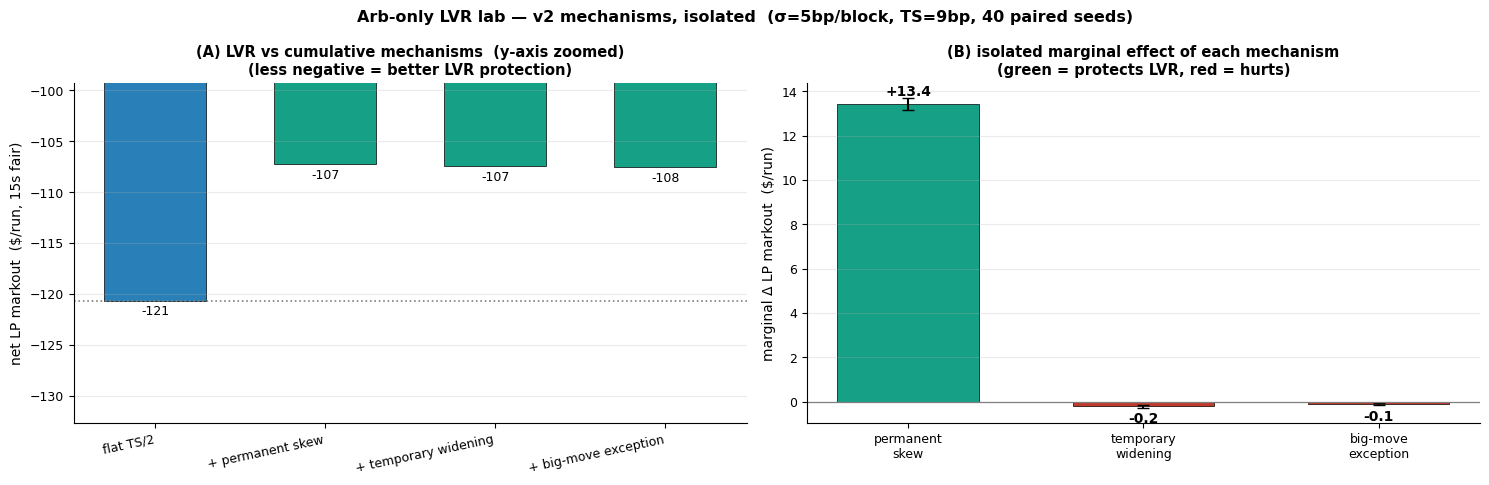

In [2]:
per = L.run_matrix(seeds=SEEDS, sigma_bps=SIGMA_BPS, ts_bps=TS_BPS, delta_max_bps=DELTA_MAX_BPS)
fig = L.plot_matrix(per)

**Reading (σ=5bp, δ_max=6bp).** Isolated marginal effect of each mechanism:

- **Permanent skew — the workhorse, ≈ +&#36;13/run (~11% of the −&#36;121 LVR).** It leans the fee toward
  the direction of the recent move, which — because arb *direction* is autocorrelated (the stale-mid
  offset, present even under a martingale) — is the direction the next arb most likely takes, so the
  common *continuation* arb pays the higher fee. Its share of LVR is even larger at low vol than at
  σ=10 (~5.6%): when moves are small relative to the 9bp spread, the directional capture dominates.
- **Temporary widening — ≈ 0 here.** Its benefit scales with the move size (it widens by the ask
  increment on move blocks), so at σ=5 it is negligible (it was +&#36;7.8 at σ=10).
- **Big-move exception — ≈ 0 here.** At σ=5 its fixed 10bp trigger is genuinely in the tail and
  fires on only ~4.5% of blocks, so it is effectively dormant (and no longer hurts — see below).

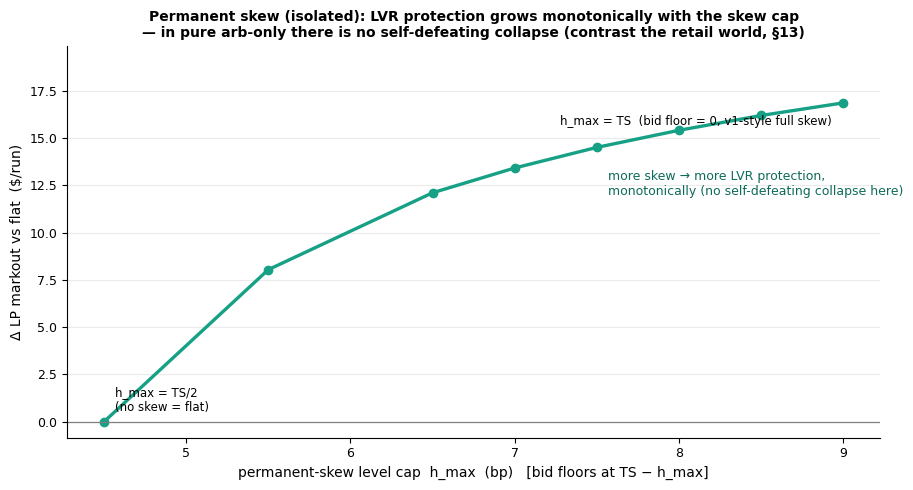

In [3]:
rows = L.run_hmax_sweep([4.5, 5.5, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0], seeds=SEEDS, sigma_bps=SIGMA_BPS,
                        delta_max_bps=DELTA_MAX_BPS)
fig = L.plot_hmax_sweep(rows)

**Reading — and a contrast with the retail world.** LVR protection grows **monotonically** with the
permanent-skew cap: even full skew (`h_max = TS`, bid floor = 0) is best, arb count roughly flat.
**No self-defeating collapse here.** That collapse (realistic_simulator §13, where aggressive skew
*backfired*) is a **retail-interaction** effect — the freed side gave away retail spread and invited
cheap reversal arbs. Isolated to pure arbitrage, the skew is cleanly beneficial; v2's `h_max` cap is
the safeguard that keeps it out of that regime once retail is present.

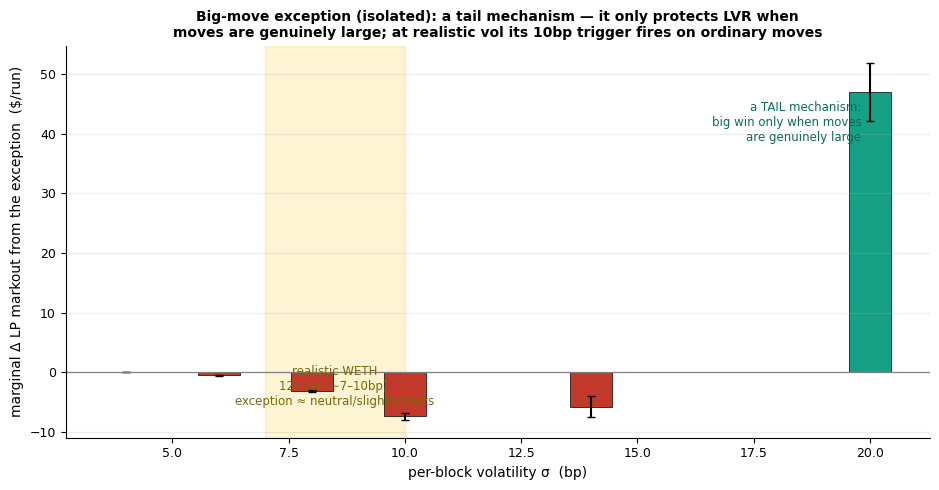

In [4]:
vol = L.run_vol_sweep([4, 6, 8, 10, 14, 20], seeds=SEEDS, ts_bps=TS_BPS, delta_max_bps=DELTA_MAX_BPS)
fig = L.plot_exception_vol(vol)

**Reading.** The exception is a **tail mechanism**: its `½·PI` widening only pays off when moves are
genuinely large (≈ +&#36;60/run at σ=20bp), is **dormant at our σ=5** (trigger rarely fires), and is
**slightly negative at moderate vol** (σ≈8–10bp), where its fixed 10bp trigger fires on *ordinary*
moves. The next chart explains *why* it can go negative — the surprising part.

{'sigma': 10.0, 'direct': 8.943235569331446, 'knock_on': -16.623151025390634, 'net': -7.679915456059186}


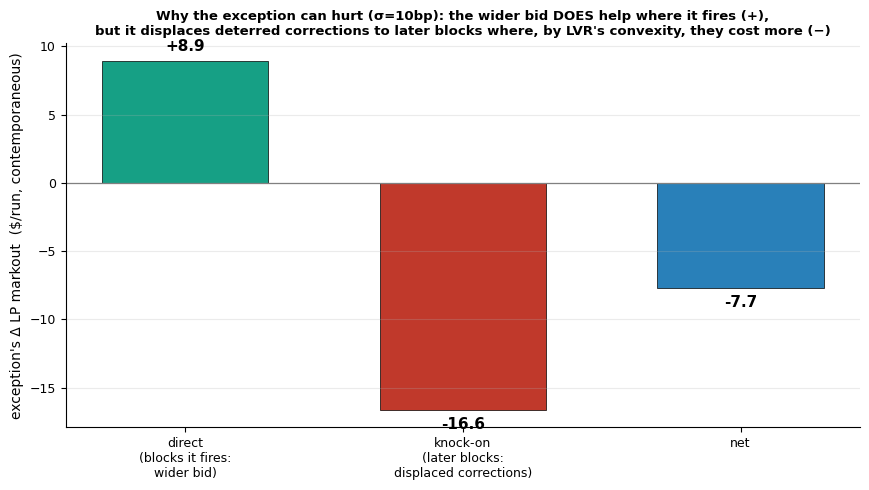

In [5]:
# Why can WIDENING the spread hurt LVR? Decompose the exception's effect at sigma=10 (where it bites)
dec = L.run_exception_decomp(sigma_bps=10.0, seeds=SEEDS, ts_bps=TS_BPS, delta_max_bps=DELTA_MAX_BPS)
print(dec)
fig = L.plot_exception_decomp(dec)

**Why the exception can hurt — and a verification it isn't a bug.** Widening the spread "should only
help" (a wider band extracts less per arb), and indeed:

- **It's not the metric.** The exception hurts the same under *contemporaneous* fair (pure LVR) as
  under 15s-forward — so it's a real LVR effect, not a forward-marking artifact.
- **The basics hold.** A wider band *does* reduce LVR in this sim, both symmetric (sweeping TS) and
  one-sided (a wider *permanent* bid) — verified. And on a controlled *reverting* path the exception
  fires on the right block and widens the right side, exactly per the doc.

So the implementation is faithful. The decomposition above shows the real story:
- **Direct effect on the blocks it fires: ≈ +&#36;9** — the wider bid *does* reduce LVR there, as expected.
- **Knock-on on later blocks: ≈ −&#36;17** — the harm. By deterring the corrective arb, the exception
  doesn't *remove* the divergence; it **displaces the correction to a later block**. Because LVR is
  **convex** in accumulated divergence, the displaced (larger) correction extracts *more* than the
  prompt one would have — and that knock-on outweighs the direct saving. **Net ≈ −&#36;8.**

Two roots: (1) a *permanent* wide bid avoids this (band always wide ⇒ corrections stay uniformly
small), but the exception's *transient, one-sided* widening just defers a correction into a normal-fee
block. (2) The **trigger is a false signal**: `PI` is the pool's *own* arb footprint — the
already-corrected fair move — not leftover un-backrun flow. The exception is built to capture the
backrun of an *uninformed* move; in pure arbitrage there is none, so it only ever mis-fires. (At high
vol the reversions are large enough to still trade and pay the wide fee, so it flips to a net win.)

## Worked micro-example — one episode, block by block

To see the mechanisms on concrete numbers, here is one deterministic episode: a quiet start, a
**+30 bp up-jump at block 2**, then the price falls back to 100. Pool starts at x=10,000, y=1,000,000
(mid = 100), TS = 9 bp.

In [6]:
L.show_v2_decomposition()

,fair,PI (bp),h_a→h_a*,h_b→h_b*,g_a,g_b,f_a,f_b,mid after,arb
blk,,,,,,,,,,
0,100.00,+0.0,4.5→4.5,4.5→4.5,0.0,0.0,4.5,4.5,100.0000,–
1,100.00,+0.0,4.5→4.5,4.5→4.5,0.0,0.0,4.5,4.5,100.0000,–
2,100.30,+0.0,4.5→4.5,4.5→4.5,0.0,0.0,4.5,4.5,100.2549,BUY
3,100.15,+25.5,4.5→7.0,4.5→2.0,0.0,15.2,7.0,17.2,100.2549,–
4,100.00,+0.0,7.0→7.0,2.0→2.0,0.0,0.0,7.0,2.0,100.0200,SELL
5,100.00,-23.4,7.0→2.0,2.0→7.0,16.7,0.0,18.7,7.0,100.0200,–


**Permanent (h) vs temporary (g), per the doc.** At **b3** the inter-block move is PI = +25.5 bp —
this is b2's *own* buy arb pushing the mid from 100 to 100.2549:
- permanent: `h_a' = min(h_a + min(β·PI, δ_max), h_max) = min(4.5 + min(12.75, 6), 7) = 7.0`,&nbsp; `h_b' = TS − h_a' = 2.0`
- temporary: `g_b = (h_b − h_b') + ½·PI = (4.5 − 2.0) + 12.75 = 15.2`,&nbsp; `g_a = 0`
- totals: `f_a = 7.0`,&nbsp; `f_b = 2.0 + 15.2 = 17.2`

The key contrast is **b4** (why it is *not* 4.5/4.5): the **permanent** skew *persists* (h = 7.0/2.0
carries over — that is what "permanent" means), while the **temporary** widening is a one-block pulse
that resets (PI = 0 ⇒ `g_b = (h_b − h_b') = 0`). So the bid drops 17.2 → **2.0**, not back to 4.5. (The
4.5/4.5 you saw earlier was the *isolated-exception* strategy below, which has no permanent skew.)

In [7]:
L.show_displacement_example()

flat total = -2.2734   flat+exception total = -2.7204   net exception effect = -0.4470


fair f_b (bp)   arb      dx       dy mid after  markout
run      blk                                                           
flat     0    100.00      4.5     –                   100.0000         
         1    100.00      4.5     –                   100.0000         
         2    100.30      4.5   BUY  12.719  1274.09  100.2549  -1.6226
         3    100.15      4.5  SELL   2.980   298.55  100.1951  -0.0890
         4    100.00      4.5  SELL   7.493   749.89  100.0450  -0.5618
         5    100.00      4.5     –                   100.0450         
flat+exc 0    100.00      4.5     –                   100.0000         
         1    100.00      4.5     –                   100.0000         
         2    100.30      4.5   BUY  12.719  1274.09  100.2549  -1.6226
         3    100.15     17.2     –                   100.2549         
         4    100.00      4.5  SELL  10.473  1048.44  100.0450  -1.0978
         5    100.00      4.5     –                   100.0450

**The displacement (isolating just the exception on a flat base).** Both runs end in the **identical**
pool state (mid 100.045) and the arber sells the **identical** total 10.473 X — the only difference is
*when*. Markout = the LP's P&L valuing the swapped tokens at that block's fair (`dy − dx·fair` when the
LP sells X, `dx·fair − dy` when it buys X), which is exactly the LVR.

- **Flat** corrects in two steps: 2.980 X at b3 (fair **100.15**) + 7.493 X at b4 (fair 100.00).
- **Exception** widens the bid to 17.2 bp at b3 → the corrective sell is **deterred** → all 10.473 X
  is corrected at b4 (fair **100.00**).

So the deferred 2.980 X is bought against a fair **0.15 lower**, an extra LP loss of
**2.980 × 0.15 = 0.447** — exactly the net effect. Deterring didn't *remove* the divergence; it
displaced the correction to a worse price.

In [8]:
L.show_branch_analysis()

,exception effect ($),note
branch,,
continuation (price keeps rising),+0.0000,inert — continuation arb pays the ask
reversion → b4 down,-0.4470,displacement cost
reversion → b4 up,+0.1781,round-trip avoided
reversion average (50/50),-0.1345,
full average (½ cont + ½ reversion),-0.0672,still negative → not bad luck


**Is the loss just an unlucky path? No.** The exception widens the **bid** (after an up-move) — the
side a *reversion* takes — so it is **inert on continuations** (a continuation arb pays the *ask*).
Averaging over the martingale's next move:
- continuation (price keeps rising): **0** (inert — the widened bid is never touched)
- reversion → b4 down: **−0.447** (displacement)
- reversion → b4 up: **+0.178** (the deferral avoids a round-trip — the doc's *intended* capture)

The down-cost exceeds the up-saving, so the reversion average is negative and the full average is too.
This is **short gamma**: holding an un-rebalanced (mispriced) position one extra block loses more when
the price moves against it than it saves when it reverts. The single −0.447 path was just the
down-branch; the *expected* effect is still negative — consistent with the ≈ −&#36;5/run over 40 random
seeds.

## Synthesis

Isolated in a clean arb-only world (martingale price, 15s-fair LVR), at σ=5bp / δ_max=6bp:

| mechanism | marginal effect | why |
|---|---|---|
| **permanent skew** | **≈ +&#36;13** (workhorse, ~11%) | leans the fee toward the autocorrelated arb direction → the common continuation arb pays more |
| **temporary widening** | ≈ 0 here | benefit scales with move size; negligible at low vol (was +&#36;7.8 at σ=10) |
| **big-move exception** | ≈ 0 here | dormant at σ=5; at moderate vol it *displaces* corrections (convex ⇒ costlier) and slightly hurts; only a tail win at high vol |

The directional **permanent skew** carries essentially all of v2's LVR protection, and — unlike the
retail world — it does not self-defeat when pushed (no retail to give away on the de-loaded side). The
temporary widening is move-size-scaled (small at low vol); the big-move exception is a
volatility-tail tool whose fixed 10bp trigger makes it dormant-to-slightly-harmful at realistic vol,
because deterring a correction merely displaces it to a later, convexly-costlier one.